# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV


# 2. Load the dataset (with features)

In [50]:
df = pd.read_csv("../data/ble_test_features.csv")

In [51]:
df.head()

,num_beacons_seen,strongest_rssi,rssi_gap_1_2,b0_rssi_norm,b0_rssi_std,b0_count,b1_rssi_norm,b1_rssi_std,b1_count,b2_rssi_norm,b2_rssi_std,b2_count,location
0,6,-66.000000,6.000000,3.107226,0.000000,17,2.373218,0.000000,17.0,-0.229579,2.826918,192.0,kitchen
1,8,-71.000000,1.000000,1.934789,0.000000,17,1.824551,0.000000,17.0,1.548956,2.537596,34.0,kitchen
2,8,-71.000000,1.000000,1.591021,0.000000,17,1.491464,0.000000,17.0,0.993679,0.000000,17.0,kitchen
3,2,-91.363636,4.636364,0.369745,4.567673,33,-0.717740,0.000000,17.0,NaN,NaN,NaN,cafeteria
4,4,-69.000000,24.620000,1.954171,0.000000,17,-0.384592,4.869271,50.0,-0.515684,0.000000,7.0,cafeteria


In [34]:
df = df.drop(columns="time")
df.head()

,count_beacon_1,count_beacon_2,count_beacon_3,count_beacon_4,count_beacon_5,count_beacon_6,count_beacon_7,count_beacon_8,count_beacon_9,count_beacon_10,...,sd_rssi_b21,mean_rssi_b22,sd_rssi_b22,mean_rssi_b23,sd_rssi_b23,mean_rssi_b24,sd_rssi_b24,mean_rssi_b25,sd_rssi_b25,location
0,214,68,34,17,68,34,17,17,17,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kitchen
1,68,0,34,17,0,67,0,0,0,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cafeteria
2,136,0,0,51,47,51,51,34,34,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cafeteria
3,238,0,0,0,55,34,17,0,0,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,cafeteria
4,17,0,0,0,0,34,17,0,0,34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,kitchen


In [35]:
df['location'].unique()

array(['kitchen', 'cafeteria', 'cleaning', 'nurse station', 'hallway',
       '501', '506', '520', '511', '523', '516', '508', 'Office Large',
       'Office Small', '213', 'Cafeteria A', '206', '212', '211', '210',
       '202', '208', '207', 'Cafeteria D', 'Cafeteria B', '522',
       'Nurse Room', 'Clean Room', '502', '518', '201', 'Bathroom',
       'Clean 9', 'Cafeteria C', '203', '517', '512', '513', '515', '503',
       '505'], dtype=object)

In [36]:
rooms_to_remove = ['201', '202', '203', '206', '207', '208', '210', '211', '212', '213', 'Office Large', 'Office Small']
df = df[~df['location'].isin(rooms_to_remove)]

In [37]:
df['location'] = df['location'].replace({'Nurse Room': 'nurse station', 
                                       'Cafeteria A': 'cafeteria', 
                                       'Cafeteria B': 'cafeteria', 
                                       'Cafeteria C': 'cafeteria',
                                       'Cafeteria D': 'cafeteria',
                                       'Clean Room': 'cleaning',
                                       'Clean 9': 'cleaning'})

In [38]:
df['location'].unique()

array(['kitchen', 'cafeteria', 'cleaning', 'nurse station', 'hallway',
       '501', '506', '520', '511', '523', '516', '508', '522', '502',
       '518', 'Bathroom', '517', '512', '513', '515', '503', '505'],
      dtype=object)

Text(0, 0.5, 'Count')

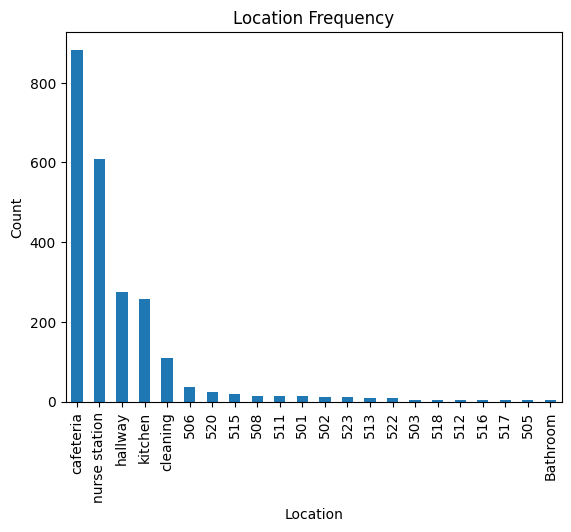

In [39]:
df['location'].value_counts().plot(kind='bar')
plt.title('Location Frequency')
plt.xlabel('Location')
plt.ylabel('Count')

In [52]:
df = df.dropna()
X = df.drop(columns='location')
X.head()

,num_beacons_seen,strongest_rssi,rssi_gap_1_2,b0_rssi_norm,b0_rssi_std,b0_count,b1_rssi_norm,b1_rssi_std,b1_count,b2_rssi_norm,b2_rssi_std,b2_count
0,6,-66.0,6.00,3.107226,0.000000,17,2.373218,0.000000,17.0,-0.229579,2.826918,192.0
1,8,-71.0,1.00,1.934789,0.000000,17,1.824551,0.000000,17.0,1.548956,2.537596,34.0
2,8,-71.0,1.00,1.591021,0.000000,17,1.491464,0.000000,17.0,0.993679,0.000000,17.0
4,4,-69.0,24.62,1.954171,0.000000,17,-0.384592,4.869271,50.0,-0.515684,0.000000,7.0
5,7,-66.5,22.50,2.065616,2.537596,34,0.066093,0.000000,17.0,0.066093,0.000000,17.0


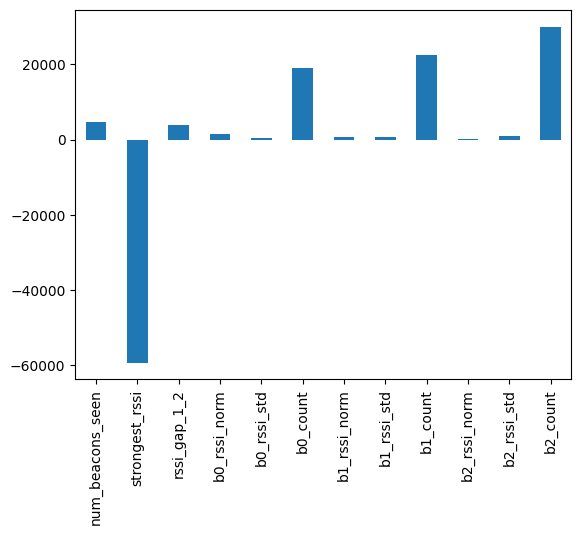

In [53]:
feature_count = X[X.columns[0:24]].sum()
feature_count.plot(kind='bar')
plt.show()

# 3. Train a random forest model

In [54]:
y = df['location']

In [55]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [56]:
split_idx = int(0.7 * len(X))

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y_encoded[:split_idx]
y_test  = y_encoded[split_idx:]

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", X.columns)
    ]
)

In [58]:
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [59]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [60]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
precision = precision_score(y_test, y_pred, average='weighted')

print(f"Accuracy: {accuracy:.2f}")
print(f"F1 score: {f1:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")

Accuracy: 0.41
F1 score: 0.44
Precision: 0.49
Recall: 0.41


c:\Users\laber\MASc\Repos\Thunderbolts-W\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\laber\MASc\Repos\Thunderbolts-W\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [61]:
transformed_feature_names = pipeline.named_steps['preprocess'].get_feature_names_out()
feature_importances = pipeline.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({
    'Feature': transformed_feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

                  Feature  Importance
1     num__strongest_rssi    0.216537
3       num__b0_rssi_norm    0.126489
0   num__num_beacons_seen    0.124576
9       num__b2_rssi_norm    0.120582
6       num__b1_rssi_norm    0.104968
2       num__rssi_gap_1_2    0.076933
11          num__b2_count    0.063521
10       num__b2_rssi_std    0.041152
8           num__b1_count    0.040710
5           num__b0_count    0.038634
7        num__b1_rssi_std    0.029252
4        num__b0_rssi_std    0.016646
